In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
rfm_df = pd.read_csv("../data/processed/customer_rfm_features.csv")

print("RFM data shape:", rfm_df.shape)

rfm_df.head()

RFM data shape: (4338, 20)


,customer_id,recency,frequency,monetary,monetary_capped,total_quantity,unique_products,avg_order_value,first_purchase,last_purchase,customer_lifetime_days,purchase_frequency_per_month,avg_quantity_per_order,monetary_per_order,product_diversity_ratio,r_score,f_score,m_score,rfm_score,rfm_segment
0,12346,326,1,77183.60,77183.600,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0,30.000000,74215.000000,77183.600000,0.000560,1,1,5,7,Medium Value
1,12347,2,7,4310.00,4166.600,2458,103,23.681319,2010-12-07 14:57:00,2011-12-07 15:52:00,365,0.573770,351.142857,615.714286,0.057639,5,5,5,15,Top Value
2,12348,75,4,1797.24,1770.240,2341,22,57.975484,2010-12-16 19:09:00,2011-09-25 13:13:00,282,0.424028,585.250000,449.310000,0.012311,2,4,4,10,High Value
3,12349,19,1,1757.55,1587.486,631,73,24.076027,2011-11-21 09:51:00,2011-11-21 09:51:00,0,30.000000,631.000000,1757.550000,0.040851,4,1,4,9,Medium Value
4,12350,310,1,334.40,332.032,197,17,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,30.000000,197.000000,334.400000,0.009513,1,1,2,4,Low Value


In [4]:
print(rfm_df.info())

print("\nMissing values:")
print(rfm_df.isnull().sum())

print("\nDuplicate customers:")
print(rfm_df["customer_id"].duplicated().sum())

print("\nRFM segment counts:")
print(rfm_df["rfm_segment"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   4338 non-null   int64  
 1   recency                       4338 non-null   int64  
 2   frequency                     4338 non-null   int64  
 3   monetary                      4338 non-null   float64
 4   monetary_capped               4338 non-null   float64
 5   total_quantity                4338 non-null   int64  
 6   unique_products               4338 non-null   int64  
 7   avg_order_value               4338 non-null   float64
 8   first_purchase                4338 non-null   str    
 9   last_purchase                 4338 non-null   str    
 10  customer_lifetime_days        4338 non-null   int64  
 11  purchase_frequency_per_month  4338 non-null   float64
 12  avg_quantity_per_order        4338 non-null   float64
 13  monetary_per_o

In [5]:
cluster_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "unique_products",
    "purchase_frequency_per_month",
    "product_diversity_ratio"
]

X = rfm_df[cluster_features].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X.head()

,recency,frequency,monetary,avg_order_value,unique_products,purchase_frequency_per_month,product_diversity_ratio
0,326,1,77183.60,77183.600000,1,30.000000,0.000560
1,2,7,4310.00,23.681319,103,0.573770,0.057639
2,75,4,1797.24,57.975484,22,0.424028,0.012311
3,19,1,1757.55,24.076027,73,30.000000,0.040851
4,310,1,334.40,19.670588,17,30.000000,0.009513


In [6]:
rfm_df["purchase_frequency_per_month_fixed"] = np.where(
    rfm_df["customer_lifetime_days"] < 30,
    rfm_df["frequency"],
    rfm_df["purchase_frequency_per_month"]
)

rfm_df["is_one_time_customer"] = (rfm_df["frequency"] == 1).astype(int)

rfm_df[[
    "customer_id",
    "frequency",
    "customer_lifetime_days",
    "purchase_frequency_per_month",
    "purchase_frequency_per_month_fixed",
    "is_one_time_customer"
]].head(10)

,customer_id,frequency,customer_lifetime_days,purchase_frequency_per_month,purchase_frequency_per_month_fixed,is_one_time_customer
0,12346,1,0,30.000000,1.000000,1
1,12347,7,365,0.573770,0.573770,0
2,12348,4,282,0.424028,0.424028,0
3,12349,1,0,30.000000,1.000000,1
4,12350,1,0,30.000000,1.000000,1
5,12352,8,260,0.919540,0.919540,0
6,12353,1,0,30.000000,1.000000,1
7,12354,1,0,30.000000,1.000000,1
8,12355,1,0,30.000000,1.000000,1
9,12356,3,302,0.297030,0.297030,0


In [7]:
cluster_features = [
    "recency",
    "frequency",
    "monetary_capped",
    "avg_order_value",
    "unique_products",
    "purchase_frequency_per_month_fixed",
    "product_diversity_ratio",
    "is_one_time_customer"
]

X = rfm_df[cluster_features].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X.head()

,recency,frequency,monetary_capped,avg_order_value,unique_products,purchase_frequency_per_month_fixed,product_diversity_ratio,is_one_time_customer
0,326,1,77183.600,77183.600000,1,1.000000,0.000560,1
1,2,7,4166.600,23.681319,103,0.573770,0.057639,0
2,75,4,1770.240,57.975484,22,0.424028,0.012311,0
3,19,1,1587.486,24.076027,73,1.000000,0.040851,1
4,310,1,332.032,19.670588,17,1.000000,0.009513,1


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

X_scaled_df.head()

,recency,frequency,monetary_capped,avg_order_value,unique_products,purchase_frequency_per_month_fixed,product_diversity_ratio,is_one_time_customer
0,2.334574,-0.425097,8.597216,52.539783,-0.708802,-0.037664,-0.708802,1.380420
1,-0.905340,0.354417,0.247408,-0.030455,0.486180,-0.506877,0.486180,-0.724417
2,-0.175360,-0.035340,-0.026626,-0.007090,-0.462776,-0.671720,-0.462776,-0.724417
3,-0.735345,-0.425097,-0.047525,-0.030186,0.134715,-0.037664,0.134715,1.380420
4,2.174578,-0.425097,-0.191091,-0.033188,-0.521354,-0.037664,-0.521354,1.380420


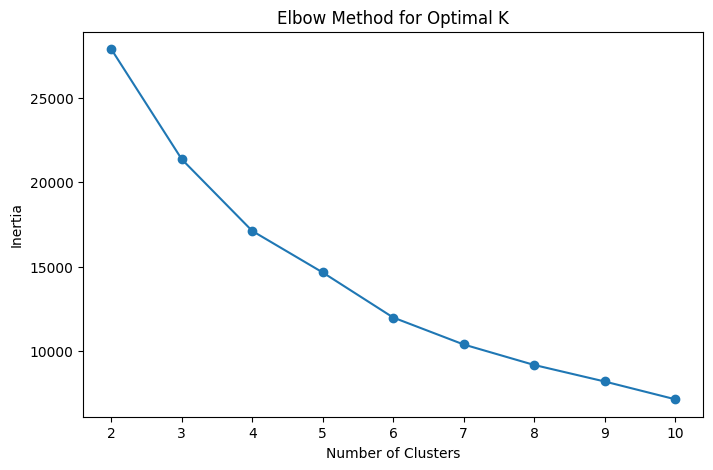

In [9]:
inertia_values = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

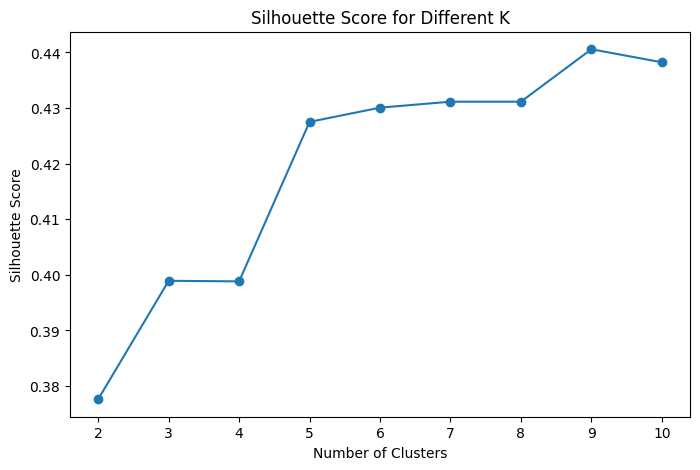

K=2: Silhouette Score = 0.3776
K=3: Silhouette Score = 0.3989
K=4: Silhouette Score = 0.3988
K=5: Silhouette Score = 0.4275
K=6: Silhouette Score = 0.4301
K=7: Silhouette Score = 0.4311
K=8: Silhouette Score = 0.4311
K=9: Silhouette Score = 0.4406
K=10: Silhouette Score = 0.4382


In [10]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker="o")
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.show()

for k, score in zip(k_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")

In [11]:
optimal_k = 6

kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm_df["cluster"] = kmeans_model.fit_predict(X_scaled)

rfm_df["cluster"].value_counts().sort_index()

cluster
0    2255
1     463
2       2
3     855
4     749
5      14
Name: count, dtype: int64

In [12]:
cluster_summary = (
    rfm_df.groupby("cluster")
    .agg(
        customer_count=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_monetary_capped=("monetary_capped", "mean"),
        avg_total_quantity=("total_quantity", "mean"),
        avg_unique_products=("unique_products", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_purchase_frequency=("purchase_frequency_per_month_fixed", "mean"),
        one_time_customer_rate=("is_one_time_customer", "mean"),
        avg_rfm_score=("rfm_score", "mean")
    )
    .reset_index()
)

cluster_summary

,cluster,customer_count,avg_recency,avg_frequency,avg_monetary,avg_monetary_capped,avg_total_quantity,avg_unique_products,avg_order_value,avg_purchase_frequency,one_time_customer_rate,avg_rfm_score
0,0,2255,55.956098,4.205322,1510.478001,1489.780561,903.046563,54.801774,39.152320,0.886575,0.000000,10.547228
1,1,463,19.807775,13.185745,6844.734600,6661.558129,3986.449244,208.779698,24.619857,1.459834,0.002160,13.881210
2,2,2,163.500000,1.500000,122828.050000,121143.370500,77606.000000,2.000000,66670.550000,0.646341,0.500000,10.000000
3,3,855,66.996491,1.000000,390.094282,385.546691,250.580117,23.941520,37.004795,1.000000,1.000000,6.230409
4,4,749,277.735648,1.229640,381.261642,377.249524,205.802403,20.052069,40.365408,1.101312,0.849132,4.467290
5,5,14,31.285714,83.214286,103372.657143,99365.246714,53307.285714,789.714286,124.140683,9.294045,0.000000,14.642857


In [13]:
def assign_business_segment(row):
    cluster = row["cluster"]

    if cluster == 5:
        return "Elite VIP Customers"
    elif cluster == 2:
        return "Extreme Bulk Buyers"
    elif cluster == 1:
        return "Loyal High-Value Customers"
    elif cluster == 0:
        return "Regular Active Customers"
    elif cluster == 3:
        return "New / One-Time Customers"
    elif cluster == 4:
        return "Dormant Low-Value Customers"
    else:
        return "Other"

rfm_df["business_segment"] = rfm_df.apply(assign_business_segment, axis=1)

rfm_df["business_segment"].value_counts()

business_segment
Regular Active Customers       2255
New / One-Time Customers        855
Dormant Low-Value Customers     749
Loyal High-Value Customers      463
Elite VIP Customers              14
Extreme Bulk Buyers               2
Name: count, dtype: int64

In [14]:
segment_mapping = (
    rfm_df[["cluster", "business_segment"]]
    .drop_duplicates()
    .sort_values("cluster")
)

cluster_summary = cluster_summary.merge(
    segment_mapping,
    on="cluster",
    how="left"
)

cluster_summary

,cluster,customer_count,avg_recency,avg_frequency,avg_monetary,avg_monetary_capped,avg_total_quantity,avg_unique_products,avg_order_value,avg_purchase_frequency,one_time_customer_rate,avg_rfm_score,business_segment
0,0,2255,55.956098,4.205322,1510.478001,1489.780561,903.046563,54.801774,39.152320,0.886575,0.000000,10.547228,Regular Active Customers
1,1,463,19.807775,13.185745,6844.734600,6661.558129,3986.449244,208.779698,24.619857,1.459834,0.002160,13.881210,Loyal High-Value Customers
2,2,2,163.500000,1.500000,122828.050000,121143.370500,77606.000000,2.000000,66670.550000,0.646341,0.500000,10.000000,Extreme Bulk Buyers
3,3,855,66.996491,1.000000,390.094282,385.546691,250.580117,23.941520,37.004795,1.000000,1.000000,6.230409,New / One-Time Customers
4,4,749,277.735648,1.229640,381.261642,377.249524,205.802403,20.052069,40.365408,1.101312,0.849132,4.467290,Dormant Low-Value Customers
5,5,14,31.285714,83.214286,103372.657143,99365.246714,53307.285714,789.714286,124.140683,9.294045,0.000000,14.642857,Elite VIP Customers


In [15]:
segment_interpretation = pd.DataFrame({
    "business_segment": [
        "Elite VIP Customers",
        "Extreme Bulk Buyers",
        "Loyal High-Value Customers",
        "Regular Active Customers",
        "New / One-Time Customers",
        "Dormant Low-Value Customers"
    ],
    "interpretation": [
        "Very small group with extremely high frequency, revenue, and product diversity.",
        "Rare customers with unusually large one-time bulk purchases.",
        "Frequent and recent customers with strong monetary value.",
        "Main customer base with moderate frequency and recent activity.",
        "Customers with only one purchase but relatively recent activity.",
        "Inactive customers with low frequency and low monetary contribution."
    ],
    "business_action": [
        "Offer exclusive loyalty benefits, early access, and personalized account management.",
        "Monitor separately as outliers; avoid letting them distort normal customer trends.",
        "Upsell, cross-sell, and provide loyalty rewards.",
        "Encourage repeat purchases through targeted campaigns.",
        "Send onboarding offers and second-purchase discounts.",
        "Run win-back campaigns or reduce marketing spend if unresponsive."
    ]
})

segment_interpretation

,business_segment,interpretation,business_action
0,Elite VIP Customers,Very small group with extremely high frequency...,"Offer exclusive loyalty benefits, early access..."
1,Extreme Bulk Buyers,Rare customers with unusually large one-time b...,Monitor separately as outliers; avoid letting ...
2,Loyal High-Value Customers,Frequent and recent customers with strong mone...,"Upsell, cross-sell, and provide loyalty rewards."
3,Regular Active Customers,Main customer base with moderate frequency and...,Encourage repeat purchases through targeted ca...
4,New / One-Time Customers,Customers with only one purchase but relativel...,Send onboarding offers and second-purchase dis...
5,Dormant Low-Value Customers,Inactive customers with low frequency and low ...,Run win-back campaigns or reduce marketing spe...


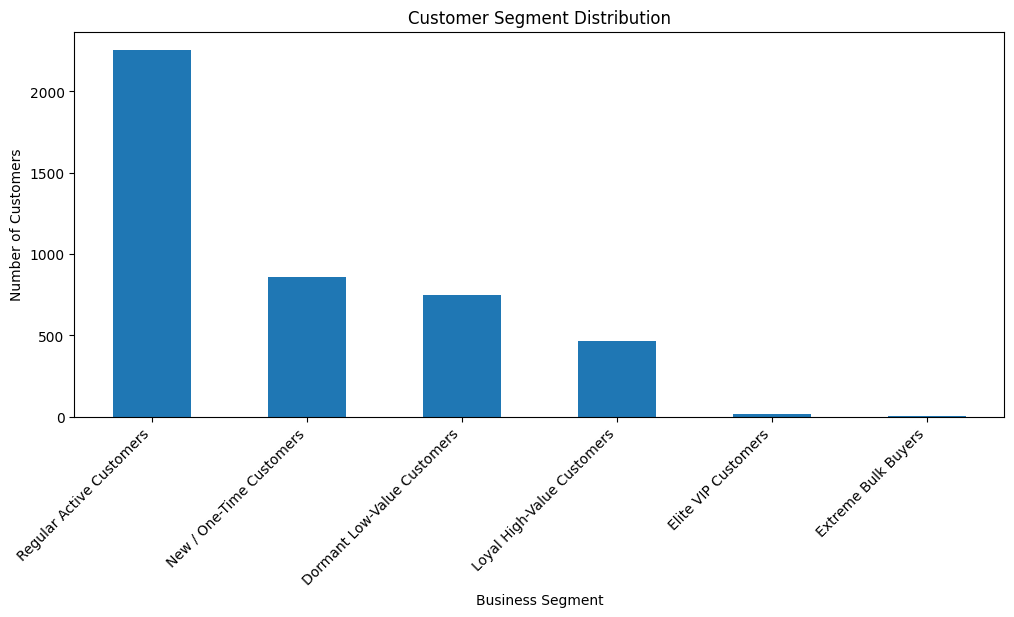

business_segment
Regular Active Customers       2255
New / One-Time Customers        855
Dormant Low-Value Customers     749
Loyal High-Value Customers      463
Elite VIP Customers              14
Extreme Bulk Buyers               2
Name: count, dtype: int64

In [16]:
segment_counts = rfm_df["business_segment"].value_counts()

plt.figure(figsize=(12, 5))
segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Business Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.show()

segment_counts

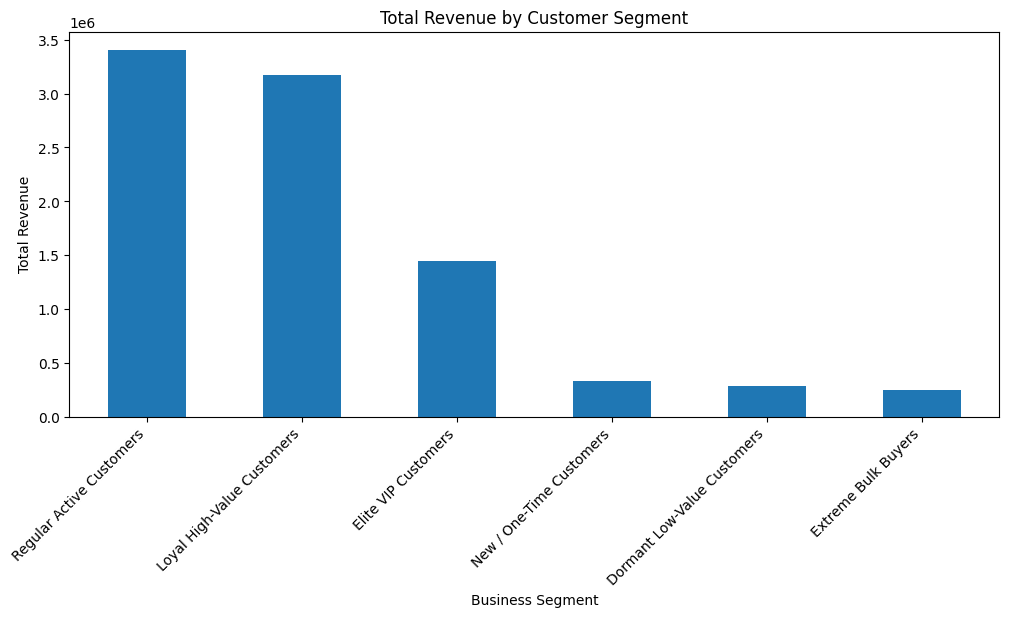

business_segment
Regular Active Customers       3406127.893
Loyal High-Value Customers     3169112.120
Elite VIP Customers            1447217.200
New / One-Time Customers        333530.611
Dormant Low-Value Customers     285564.970
Extreme Bulk Buyers             245656.100
Name: monetary, dtype: float64

In [17]:
segment_revenue = (
    rfm_df.groupby("business_segment")["monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
segment_revenue.plot(kind="bar")

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Business Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")

plt.show()

segment_revenue

DBSCAN

In [19]:
from sklearn.preprocessing import StandardScaler

dbscan_features = [
    "recency",
    "frequency",
    "monetary_capped",
    "total_quantity",
    "unique_products",
    "avg_order_value",
    "purchase_frequency_per_month_fixed",
    "product_diversity_ratio"
]

X_dbscan = rfm_df[dbscan_features].copy()

scaler = StandardScaler()

X_dbscan_scaled = scaler.fit_transform(X_dbscan)

print(X_dbscan_scaled.shape)

(4338, 8)


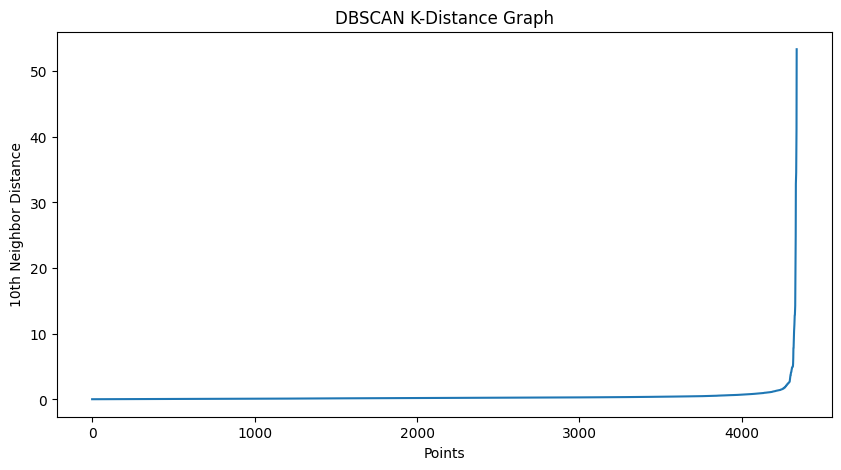

In [20]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(
    n_neighbors=10
)

neighbors_fit = neighbors.fit(X_dbscan_scaled)

distances, indices = neighbors_fit.kneighbors(
    X_dbscan_scaled
)

distances = np.sort(
    distances[:, 9]
)

plt.figure(figsize=(10,5))

plt.plot(distances)

plt.title("DBSCAN K-Distance Graph")
plt.xlabel("Points")
plt.ylabel("10th Neighbor Distance")

plt.show()

In [21]:
from sklearn.cluster import DBSCAN

eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_dbscan_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_points = list(labels).count(-1)

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": noise_points,
            "noise_percentage": round(noise_points / len(labels) * 100, 2)
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df

,eps,min_samples,clusters,noise_points,noise_percentage
0,1.5,5,1,59,1.36
1,1.5,10,1,62,1.43
2,1.5,15,1,68,1.57
3,2.0,5,1,42,0.97
4,2.0,10,1,44,1.01
5,2.0,15,1,48,1.11
6,2.5,5,1,32,0.74
7,2.5,10,1,38,0.88
8,2.5,15,1,41,0.95
9,3.0,5,2,26,0.60


In [22]:
best_dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

dbscan_labels = best_dbscan.fit_predict(
    X_dbscan_scaled
)

rfm_df["dbscan_cluster"] = dbscan_labels

rfm_df["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1      26
 0    4308
 1       4
Name: count, dtype: int64

In [23]:
cluster_summary_dbscan = (
    rfm_df.groupby("dbscan_cluster")
    .agg({
        "customer_id":"count",
        "recency":"mean",
        "frequency":"mean",
        "monetary_capped":"mean",
        "total_quantity":"mean"
    })
    .reset_index()
)

cluster_summary_dbscan

,dbscan_cluster,customer_id,recency,frequency,monetary_capped,total_quantity
0,-1,26,48.423077,57.730769,83022.958131,46517.500000
1,0,4308,92.883008,3.902739,1481.076198,891.305246
2,1,4,6.000000,54.500000,37571.478750,25701.000000


In [24]:
dbscan_summary = pd.DataFrame({
    "method": ["K-Means", "DBSCAN"],
    "purpose": [
        "Primary customer segmentation",
        "Outlier and density-based customer detection"
    ],
    "result": [
        "Created 6 meaningful business segments",
        "Detected majority customers and small high-value/outlier groups"
    ],
    "final_decision": [
        "Selected for dashboard segmentation",
        "Used as supporting analysis only"
    ]
})

dbscan_summary

,method,purpose,result,final_decision
0,K-Means,Primary customer segmentation,Created 6 meaningful business segments,Selected for dashboard segmentation
1,DBSCAN,Outlier and density-based customer detection,Detected majority customers and small high-val...,Used as supporting analysis only


In [26]:
rfm_df.to_csv("../data/processed/customer_segments_with_dbscan.csv", index=False)
cluster_summary_dbscan.to_csv("../data/processed/dbscan_cluster_summary.csv", index=False)
dbscan_summary.to_csv("../data/processed/customer_segmentation_method_comparison.csv", index=False)

print("DBSCAN outputs saved successfully.")

DBSCAN outputs saved successfully.


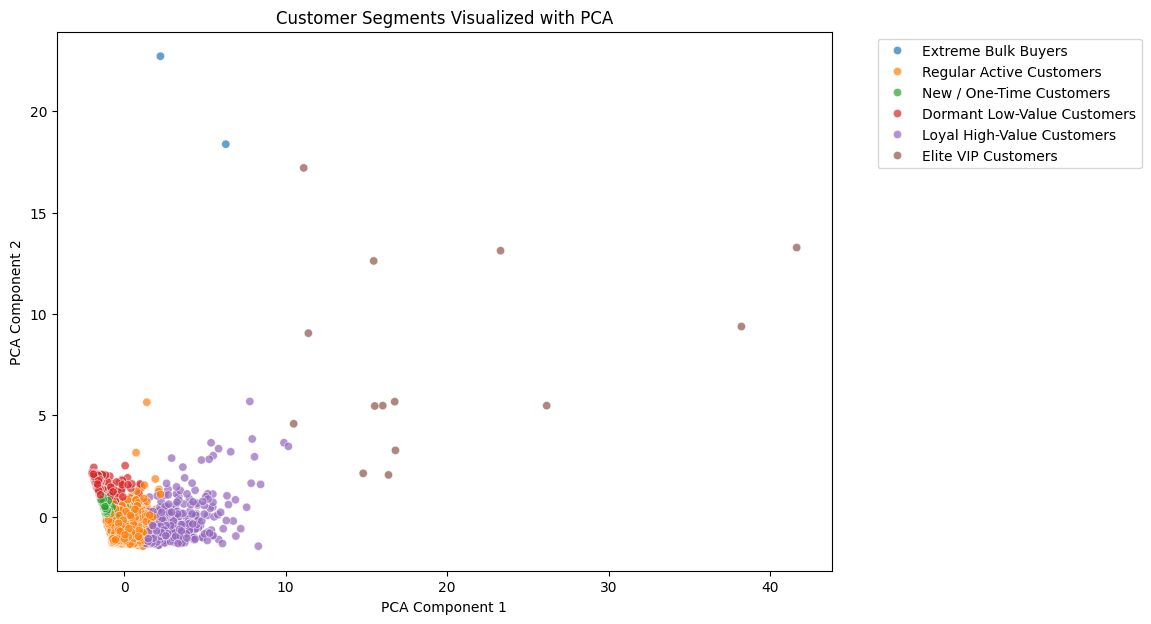

In [17]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

rfm_df["pca_1"] = pca_result[:, 0]
rfm_df["pca_2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm_df,
    x="pca_1",
    y="pca_2",
    hue="business_segment",
    palette="tab10",
    alpha=0.7
)

plt.title("Customer Segments Visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [21]:
rfm_df.to_csv("../data/processed/customer_segments.csv", index=False)
cluster_summary.to_csv("../data/processed/customer_segment_summary.csv", index=False)
segment_interpretation.to_csv("../data/processed/customer_segment_interpretation.csv", index=False)

joblib.dump(kmeans_model, "../models/customer_segmentation_kmeans.pkl")
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")

print("Customer segmentation outputs saved successfully.")

Customer segmentation outputs saved successfully.


In [22]:
print("Customer Segmentation Completed Successfully!")

print("\nSelected Model: K-Means Clustering")
print("Number of Clusters:", optimal_k)
print("Silhouette Score for K=6: 0.4301")

print("\nFinal Business Segments:")
print(rfm_df["business_segment"].value_counts())

print("\nFiles Saved:")
print("1. data/processed/customer_segments.csv")
print("2. data/processed/customer_segment_summary.csv")
print("3. data/processed/customer_segment_interpretation.csv")
print("4. models/customer_segmentation_kmeans.pkl")
print("5. models/customer_segmentation_scaler.pkl")

Customer Segmentation Completed Successfully!

Selected Model: K-Means Clustering
Number of Clusters: 6
Silhouette Score for K=6: 0.4301

Final Business Segments:
business_segment
Regular Active Customers       2255
New / One-Time Customers        855
Dormant Low-Value Customers     749
Loyal High-Value Customers      463
Elite VIP Customers              14
Extreme Bulk Buyers               2
Name: count, dtype: int64

Files Saved:
1. data/processed/customer_segments.csv
2. data/processed/customer_segment_summary.csv
3. data/processed/customer_segment_interpretation.csv
4. models/customer_segmentation_kmeans.pkl
5. models/customer_segmentation_scaler.pkl
